# AI-Engram - ResNet18 / CIFAR-100 (self-contained, Colab-ready)

The original `fig_` notebook code is kept **as-is**; only `from engram import ...` is replaced by the **engram source modules inlined below** (no install needed). A quick single-class validation cell is inserted before the full sweep. (GPU recommended; 100 classes -> tens of minutes)

In [1]:
# ===== engram/__init__.py  (verbatim from the engram package) =====
import torch
import torch.nn as nn
import logging
import gc
import copy
from dataclasses import dataclass, field
from typing import Dict, List, Optional, Type, Any, Union, Tuple
from abc import ABC, abstractmethod
from tqdm import tqdm
from pathlib import Path

import os
from tqdm.auto import tqdm
from concurrent.futures import ThreadPoolExecutor, as_completed


# --- Logging Setup ---
logger = logging.getLogger("EngramEditor")
logger.setLevel(logging.INFO)
if not logger.handlers:
    handler = logging.StreamHandler()
    handler.setFormatter(logging.Formatter('%(levelname)s: %(message)s'))
    logger.addHandler(handler)

@dataclass
class EditorConfig:
    """Configuration for AI Engram identification and editing."""
    device: torch.device = field(default_factory=lambda: torch.device("cuda" if torch.cuda.is_available() else "cpu"))
    storage_device: torch.device = torch.device("cpu") 
    precision: torch.dtype = torch.float64            
    damping_factor: float = 0.0                       # Set to 0.0 to rely on pinv's SVD thresholding
    edit_strength: float = 1.0                        # Alpha in Eq.(16)
    verbose: bool = True

# --- Layer Handlers ---

class LayerHandler(ABC):
    @abstractmethod
    def get_input_dim(self, module: nn.Module) -> int: pass
    @abstractmethod
    def reshape_input(self, module: nn.Module, inputs: Any) -> torch.Tensor: pass

class LinearHandler(LayerHandler):
    def get_input_dim(self, module: nn.Linear): return module.in_features
    def reshape_input(self, module: nn.Linear, inputs: Any):
        return inputs[0].reshape(-1, module.in_features)

class Conv2dHandler(LayerHandler):
    def get_input_dim(self, module: nn.Conv2d):
        return module.in_channels * module.kernel_size[0] * module.kernel_size[1]
    def reshape_input(self, module: nn.Conv2d, inputs: Any):
        # Optimized unfolding matching the original script
        x = inputs[0]
        unfolded = torch.nn.functional.unfold(
            x, module.kernel_size, module.dilation, module.padding, module.stride
        )
        return unfolded.transpose(1, 2).reshape(-1, unfolded.size(1))

class MaskedLinearHandler(LinearHandler):
    def __init__(self):
        self.current_mask = None

    def reshape_input(self, module: nn.Linear, inputs: Any):
        x = inputs[0] # [Batch, Seq, Dim]
        if self.current_mask is not None:
            mask = self.current_mask.to(x.device).view(-1)
            x_flat = x.reshape(-1, module.in_features)
            return x_flat[mask] 
        return super().reshape_input(module, inputs)    
    
# --- Core Statistics Engine ---

class CovarianceCollector:
    """Efficiently accumulates covariance matrices for ALL supported layers."""
    def __init__(self, model: nn.Module, config: EditorConfig, registry: Dict[Type[nn.Module], LayerHandler], target_layers: Optional[List[str]] = None):
        self.model = model
        self.config = config
        self.registry = registry
        self.target_layers = target_layers
        self.covariance_matrices: Dict[str, torch.Tensor] = {}
        self._hook_handles: List[Any] = []

    def __enter__(self):
        for name, module in self.model.named_modules():
            # If target_layers is provided, filter; otherwise, collect ALL supported layers
            if self.target_layers and name not in self.target_layers: continue
            
            # Find matching handler
            handler = next((h for cls, h in self.registry.items() if isinstance(module, cls)), None)
            if handler:
                dim = handler.get_input_dim(module)
                self.covariance_matrices[name] = torch.zeros(
                    (dim, dim), device=self.config.storage_device, dtype=self.config.precision
                )
                
                def make_hook(layer_name, layer_handler):
                    def hook(mod, inputs):
                        x = layer_handler.reshape_input(mod, inputs).to(self.config.precision)
                        covariance_chunk = x.mT @ x 
                        # Synchronous addition for maximum numerical stability
                        self.covariance_matrices[layer_name].add_(covariance_chunk.to(self.config.storage_device))
                    return hook
                self._hook_handles.append(module.register_forward_pre_hook(make_hook(name, handler)))
        return self

    def __exit__(self, exc_type, exc_val, exc_tb):
        for h in self._hook_handles: h.remove()
        torch.cuda.empty_cache()

class PreActivationCollector:
    """
    Collects the global average of pre-activation values (outputs) for targeted layers.
    Designed to work with the same layers as CovarianceCollector.
    """
    def __init__(self, model: nn.Module, config: EditorConfig, target_layers: Optional[List[str]] = None):
        self.model = model
        self.config = config
        self.target_layers = target_layers
        
        # Dictionary to store running sum of activations and total sample counts
        self.sum_activities: Dict[str, torch.Tensor] = {}
        self.total_count: Dict[str, int] = {}
        self._hook_handles: List[Any] = []

    def __enter__(self):
        """Register forward hooks to capture layer outputs."""
        for name, module in self.model.named_modules():
            # Filter by target_layers if provided
            if self.target_layers and name not in self.target_layers:
                continue
            
            # Target common weight-bearing layers (Linear, Conv2d)
            if isinstance(module, (nn.Linear, nn.Conv2d)):
                def make_hook(layer_name):
                    def hook(mod, inputs, output):
                        # 1. Capture the pre-activation (output of Wx + b)
                        z = output.detach()
                        
                        # 2. Apply Dimensionality Reduction (Global Average Pooling)
                        if z.dim() == 4:   # Conv2d: [Batch, Channel, H, W] -> [Batch, Channel]
                            z = z.mean(dim=(2, 3))
                        elif z.dim() == 3: # Sequential: [Batch, Seq, Dim] -> [Batch, Dim]
                            z = z.mean(dim=1)
                        
                        # 3. Compute Batch Statistics
                        batch_size = z.size(0)
                        # Accumulate in float64 on storage device for numerical precision
                        batch_sum = z.sum(dim=0).to(self.config.storage_device, dtype=torch.float64)

                        # 4. Update Global Statistics
                        if layer_name not in self.sum_activities:
                            self.sum_activities[layer_name] = batch_sum
                            self.total_count[layer_name] = batch_size
                        else:
                            self.sum_activities[layer_name].add_(batch_sum)
                            self.total_count[layer_name] += batch_size
                    return hook

                # Register forward hook (captures the result of the layer operation)
                self._hook_handles.append(module.register_forward_hook(make_hook(name)))
        return self

    def __exit__(self, exc_type, exc_val, exc_tb):
        """Remove all hooks to prevent memory leaks."""
        for h in self._hook_handles:
            h.remove()
        self._hook_handles.clear()

    def get_averages(self) -> Dict[str, torch.Tensor]:
        """
        Calculates and returns the final average pre-activation vectors.
        Returns: Dict {layer_name: mean_vector_tensor}
        """
        averages = {}
        for name in self.sum_activities:
            count = self.total_count[name]
            if count > 0:
                averages[name] = (self.sum_activities[name] / count).to(torch.float32)
        return averages

    
    
class EngramEditor:
    def __init__(self, model: nn.Module, config: Optional[EditorConfig] = None):
        self.model = model
        self.config = config or EditorConfig()
        self.registry = {nn.Linear: LinearHandler(), nn.Conv2d: Conv2dHandler()}

    def _move_to_device(self, data: Any) -> Any:
        """Recursively moves tensors in any data structure to the configured device."""
        if torch.is_tensor(data):
            return data.to(self.config.device)
        elif isinstance(data, dict):
            return {k: self._move_to_device(v) for k, v in data.items()}
        elif isinstance(data, (list, tuple)):
            return type(data)(self._move_to_device(v) for v in data)
        return data

    def collect_statistics(self, dataloader, target_layers: Optional[List[str]] = None, batch_fn=None):
        """Accumulates covariance matrices with robust support for nested inputs (HF models)."""
        logger.info(f"Collecting statistics. Detection: {'Selective' if target_layers else 'Full Auto'}")
        collector = CovarianceCollector(self.model, self.config, self.registry, target_layers)
        self.model.eval()
        
        with collector, torch.inference_mode():
            for batch in tqdm(dataloader, disable=not self.config.verbose, desc="Computing Covariances"):
                # 1. Extract raw inputs
                raw_inputs = batch_fn(batch) if batch_fn else batch[0]
                
                # 2. Recursively move all tensors to the correct device
                inputs = self._move_to_device(raw_inputs)
                
                # 3. Smart Forward: Handling various input patterns
                try:
                    if isinstance(inputs, dict):
                        # Pattern: model(**input_dict)
                        self.model(**inputs)
                    elif isinstance(inputs, (list, tuple)):
                        # Handling Hugging Face common pattern: (input_dict, labels)
                        if len(inputs) > 0 and isinstance(inputs[0], dict):
                            # Pass only the feature dictionary as kwargs
                            self.model(**inputs[0])
                        else:
                            # Standard pattern: model(arg1, arg2, ...)
                            self.model(*inputs)
                    else:
                        # Single tensor or custom object
                        self.model(inputs)
                except Exception as e:
                    # Final fallback: Just try to pass as is
                    logger.debug(f"Standard forward failed, trying raw input fallback. Error: {e}")
                    self.model(inputs)
                    
        return collector.covariance_matrices

#     @staticmethod
#     def merge_statistics(*stats_dicts: Dict[str, torch.Tensor]) -> Dict[str, torch.Tensor]:
#         """Sums multiple covariance dictionaries."""
#         if not stats_dicts: return {}
#         merged = {}
#         for d in stats_dicts:
#             for k, v in d.items():
#                 merged[k] = merged.get(k, 0) + v
#         return merged    
    
    @staticmethod
    def merge_statistics(*stats_dicts: Dict[str, torch.Tensor]) -> Dict[str, torch.Tensor]:
        if not stats_dicts: return {}
    
        merged = {k: v.clone() for k, v in stats_dicts[0].items()}

        for d in stats_dicts[1:]:
            for k, v in d.items():
                if k in merged:
                    merged[k].add_(v)
                else:
                    merged[k] = v.clone()
        return merged
    
    
    @torch.no_grad()
    def compute_engram_weights(self, 
                               target_covariances: Union[Dict[str, torch.Tensor], List[Dict[str, torch.Tensor]]], 
                               total_covariance: Dict[str, torch.Tensor]) -> Dict[str, torch.Tensor]:
        """
        [Function 1] Calculates the AI Engram weights (W_engram).
        Formula: W_engram = W_original @ Pos_Cov @ pinv(Total_Cov)
        """
        if isinstance(target_covariances, list):
            target_covariances = self.merge_statistics(*target_covariances)

        engram_weights = {}
        modules = dict(self.model.named_modules())

        for layer_name, pos_cov in tqdm(target_covariances.items()):
            if layer_name not in total_covariance:
                continue
            
            module = modules[layer_name]
            sum_cov = total_covariance[layer_name].to(self.config.device, dtype=self.config.precision)
            pos_cov = pos_cov.to(self.config.device, dtype=self.config.precision)
            
            original_weight = module.weight.to(self.config.precision)
            original_shape = original_weight.shape
            
            if isinstance(module, nn.Conv2d):
                original_weight = original_weight.reshape(original_shape[0], -1)

            if self.config.damping_factor > 0:
                damping_matrix = self.config.damping_factor * torch.eye(
                    sum_cov.shape[0], device=self.config.device, dtype=self.config.precision
                )
                sum_cov = sum_cov + damping_matrix

            w_engram = original_weight @ pos_cov @ torch.linalg.pinv(sum_cov)
            engram_weights[layer_name] = w_engram.reshape(original_shape)

        return engram_weights

    @torch.no_grad()
    def apply_engram_weights(self, 
                             engram_weights: Dict[str, torch.Tensor], 
                             edit_strength: Optional[float] = None,
                             inplace: bool = False) -> nn.Module:
        """
        [Function 2] Updates the model by subtracting provided Engram weights.
        """
        edit_model = self.model if inplace else copy.deepcopy(self.model)
        strength = edit_strength if edit_strength is not None else self.config.edit_strength
        
        modules = dict(edit_model.named_modules())
        for layer_name, w_engram in engram_weights.items():
            if layer_name in modules:
                module = modules[layer_name]
                update = (strength * w_engram).to(module.weight.dtype)
                module.weight.copy_(module.weight - update)
                
        return edit_model

    @torch.no_grad()
    def edit(self, 
             target_covariances: Union[Dict[str, torch.Tensor], List[Dict[str, torch.Tensor]]], 
             total_covariance: Dict[str, torch.Tensor], 
             edit_strength: Optional[float] = None,
             inplace: bool = False) -> nn.Module:
        """
        [Combined API] Computes engrams and applies the edit in one call.
        """
        # 1. Logic for engram calculation
        engram_weights = self.compute_engram_weights(target_covariances, total_covariance)
        
        # 2. Logic for model updating
        logger.info(f"Applying surgical edit to {len(engram_weights)} layers...")
        edited_model = self.apply_engram_weights(engram_weights, edit_strength, inplace)
        
        logger.info("Engram disentanglement complete.")
        return edited_model

    def collect_pre_activations(self, dataloader, target_layers: Optional[List[str]] = None, batch_fn=None):
        """
        High-level API to collect average pre-activations for analysis.
        """
        logger.info(f"Collecting pre-activation averages for {'specified' if target_layers else 'all'} layers.")
        collector = PreActivationCollector(self.model, self.config, target_layers)
        self.model.eval()

        with collector, torch.inference_mode():
            for batch in tqdm(dataloader, desc="Capturing Activations", disable=not self.config.verbose):
                raw_inputs = batch_fn(batch) if batch_fn else batch[0]
                inputs = self._move_to_device(raw_inputs)

                try:
                    if isinstance(inputs, dict):
                        self.model(**inputs)
                    elif isinstance(inputs, (list, tuple)):
                        # Handle (input_dict, labels) or similar nested patterns
                        if len(inputs) > 0 and isinstance(inputs[0], dict):
                            self.model(**inputs[0])
                        else:
                            self.model(*inputs)
                    else:
                        self.model(inputs)
                except Exception as e:
                    logger.error(f"Forward pass failed: {e}")

        return collector.get_averages()
    @torch.no_grad()
    def get_engram_magnitude(self, target_cov: Dict[str, torch.Tensor], total_cov: Dict[str, torch.Tensor]) -> Dict[str, Dict[str, float]]:
        """Analyzes localization of the memory trace."""
        logger.info("Analyzing trace magnitudes...")
        results = {}
        # ... logic as implemented before but with the refined projection above ...
        return results

    def save_statistics(self, stats, path): torch.save(stats, path); logger.info(f"Saved: {path}")
    def load_statistics(self, path): return torch.load(path, map_location=self.config.storage_device)

    def load_cov_matrix(self, path, device):
        """Load a tensor directly from a file path."""
        return torch.load(path, map_location=device, weights_only=True)

    def merge_statistics_from_files(self, file_paths, device="cuda", max_workers=None):
        """
        Args:
            file_paths (list): list of full file paths to merge
            device (str): device to load onto (cuda, cpu, ...)
            max_workers (int, optional): number of threads for parallel loading
        """
        if max_workers is None:
            max_workers = min(16, max(2, (os.cpu_count() or 8)))
            
        total_cov = None
        pbar = tqdm(total=len(file_paths), desc="Merging Statistics")

        with torch.inference_mode():
            with ThreadPoolExecutor(max_workers=max_workers) as ex:
                path_iter = iter(file_paths)
                inflight = {}

                for _ in range(min(max_workers, len(file_paths))):
                    try:
                        path = next(path_iter)
                        future = ex.submit(self.load_cov_matrix, path, device)
                        inflight[future] = path
                    except StopIteration:
                        break

                while inflight:
                    for fut in as_completed(inflight.keys()):
                        target_cov = fut.result()
                        
                        # perform the merge
                        if total_cov is None:
                            total_cov = target_cov
                        else:
                            total_cov = self.merge_statistics(total_cov, target_cov)
                        
                        del target_cov
                        del inflight[fut]
                        pbar.update(1)

                        try:
                            next_path = next(path_iter)
                            future = ex.submit(self.load_cov_matrix, next_path, device)
                            inflight[future] = next_path
                        except StopIteration:
                            pass

                        break 

        pbar.close()
        return total_cov

In [2]:
# ===== engram/models/cnn.py  (verbatim from the engram package) =====
import torch
import torch.nn as nn
from torchvision import models
from huggingface_hub import hf_hub_download

def load_resnet18_cifar(num_classes):
    m = models.resnet18(weights=None, num_classes=num_classes)
    m.conv1 = nn.Conv2d(3, 64, kernel_size=3, stride=1, padding=1, bias=False)
    m.maxpool = nn.Identity()
    return m

def load_pretrained_from_hf(dataset):
    HF_REPOS = {
        "cifar10":  {"repo_id": "edadaltocg/resnet18_cifar10",  "filename": "pytorch_model.bin", "num_classes": 10},
        "cifar100": {"repo_id": "edadaltocg/resnet18_cifar100", "filename": "pytorch_model.bin", "num_classes": 100},
    }
    spec = HF_REPOS[dataset]
    ckpt_path = hf_hub_download(repo_id=spec["repo_id"], filename=spec["filename"])
    obj = torch.load(ckpt_path, map_location="cpu")

    if isinstance(obj, dict) and "state_dict" in obj:
        state_dict = obj["state_dict"]
    else:
        state_dict = obj

    cleaned = {}
    for k, v in state_dict.items():
        nk = k
        for pref in ("module.", "model."):
            if nk.startswith(pref):
                nk = nk[len(pref):]
        cleaned[nk] = v

    model = load_resnet18_cifar(spec["num_classes"])
    missing, unexpected = model.load_state_dict(cleaned, strict=False)
    if missing:
        print(f"[warn] missing keys: {missing[:5]}{' ...' if len(missing)>5 else ''}")
    if unexpected:
        print(f"[warn] unexpected keys: {unexpected[:5]}{' ...' if len(unexpected)>5 else ''}")
    return model

def resnet18_cifar10(pretrained=True):
    if pretrained:
        return load_pretrained_from_hf("cifar10")
    return load_resnet18_cifar(num_classses=10)

def resnet18_cifar100(pretrained=True):
    if pretrained:
        return load_pretrained_from_hf("cifar100")
    return load_resnet18_cifar(num_classses=100)

In [3]:
# ===== engram/data/cifar.py  (verbatim from the engram package) =====
import torch
from torchvision import datasets, transforms
from torch.utils.data import Subset, DataLoader
import numpy as np

CIFAR_MEAN = [0.4914, 0.4822, 0.4465]
CIFAR_STD  = [0.2471, 0.2435, 0.2616]

train_transform = transforms.Compose([
    transforms.RandomCrop(32, padding=4),
    transforms.RandomHorizontalFlip(),
    transforms.ToTensor(),
    transforms.Normalize(CIFAR_MEAN, CIFAR_STD),
])

test_transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize(CIFAR_MEAN, CIFAR_STD),
])

def filter_and_sample(dataset, targets, num_samples):
    indices = np.arange(len(dataset))
    if targets is not None:
        targets_array = np.array(dataset.targets)
        mask = np.isin(targets_array, targets)
        indices = indices[mask]

    if num_samples is not None and num_samples < len(indices):
        indices = np.random.choice(indices, size=num_samples, replace=False)
    return Subset(dataset, indices)

def cifar10(split=None, targets: list = None, num_samples: int = None, batch_size=100, shuffle=False, root='../cache/data'):
    def get_data_loader(split):
        train = True if split=='train' else False
        transform = train_transform if split=='train' else test_transform
        
        dataset = datasets.CIFAR10(root=root, train=train, download=True, transform=transform)
        dataset = filter_and_sample(dataset, targets, num_samples)
        data_loader = DataLoader(dataset, batch_size=batch_size, shuffle=shuffle)
        return data_loader

    if split is None:
        return {split:get_data_loader(split) for split in ['train', 'test']}
    else:
        return get_data_loader(split)

def cifar100(split=None, targets: list = None, num_samples: int = None, batch_size=100, shuffle=False, root='../cache/data'):
    def get_data_loader(split):
        train = True if split=='train' else False
        transform = train_transform if split=='train' else test_transform
        
        dataset = datasets.CIFAR100(root=root, train=train, download=True, transform=transform)
        dataset = filter_and_sample(dataset, targets, num_samples)
        data_loader = DataLoader(dataset, batch_size=batch_size, shuffle=shuffle)
        return data_loader

    if split is None:
        return {split:get_data_loader(split) for split in ['train', 'test']}
    else:
        return get_data_loader(split)

In [4]:
# ===== engram/metric/__init__.py  (verbatim from the engram package) =====
import torch
import torch.nn.functional as F
from tqdm import tqdm

@torch.inference_mode()
def compute_classwise_accuracy(model, dataloader, num_classes, device=None, batch_fn=None):
    device = device if device else torch.device('cuda' if torch.cuda.is_available() else 'cpu')

    model.eval().to(device)
        
    class_correct = torch.zeros(num_classes, dtype=torch.float, device=device)
    class_total = torch.zeros(num_classes, dtype=torch.float, device=device)
    if batch_fn is None:
        batch_fn = lambda batch: (batch[0].to(device), batch[1].to(device))
       
    for batch in tqdm(dataloader):
        inputs, labels = batch_fn(batch)
       
        # Forward pass: handle dict or tensor inputs, extract logits
        if device.type == 'cuda':
            with torch.amp.autocast('cuda', dtype=torch.float16):
                if isinstance(inputs, dict):
                    outputs = model(**inputs)
                    if hasattr(outputs, 'logits'):
                        outputs = outputs.logits
                else:
                    outputs = model(inputs)
        else:
            if isinstance(inputs, dict):
                outputs = model(**inputs)
                if hasattr(outputs, 'logits'):
                    outputs = outputs.logits
            else:
                outputs = model(inputs)
       
        _, predicted = torch.max(outputs, 1)
       
        correct = (predicted == labels).float()
        class_correct.scatter_add_(0, labels, correct)
        class_total.scatter_add_(0, labels, torch.ones_like(correct))

    classwise_accuracy = {}
    for i in range(num_classes):
        if class_total[i] > 0:
            classwise_accuracy[i] = float((class_correct[i] / class_total[i]).item())
   
    return classwise_accuracy

def compute_cosine_similarity(x: torch.Tensor) -> torch.Tensor:
    """
    Computes the pairwise cosine similarity matrix for a given tensor.
    
    Args:
        x: Input tensor of shape [num_classes, feature_dim] (e.g., [10, 500])
        
    Returns:
        A symmetric matrix of shape [num_classes, num_classes] 
        where entry (i, j) is the cosine similarity between row i and row j.
    """
    x_normalized = F.normalize(x, p=2, dim=1, eps=1e-8)
    sim_matrix = torch.mm(x_normalized, x_normalized.t())
    
    return sim_matrix

In [5]:
# Map the names used by the original fig_ notebook to the inlined definitions

import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
load_model = resnet18_cifar100
load_data = cifar100

In [6]:
# ===== Quick validation: single-class editing sanity check =====
# Before the full sweep, run the pipeline (cov -> edit -> eval) on ONE class with
# small samples. If the target class accuracy drops, single-class editing works.
import torch as _t
_PROBE = [0, 1, 2, 3, 4]          # a few classes -> invertible G_total
_VAL_T = _PROBE[0]                 # class to unlearn in this check
_NS = 256                         # small per-class sample (speed)
_vm = load_model().to("cuda")
_ve = EngramEditor(_vm, EditorConfig())
_pos = _ve.collect_statistics(load_data(split="train", targets=[_VAL_T], num_samples=_NS))
_tot = _ve.merge_statistics(*[_ve.collect_statistics(load_data(split="train", targets=[c], num_samples=_NS)) for c in _PROBE])
_test = load_data(split="test", targets=_PROBE)
_a0 = compute_classwise_accuracy(_vm, _test, max(_PROBE) + 1)
_a1 = compute_classwise_accuracy(_ve.edit(_pos, _tot), _test, max(_PROBE) + 1)
print(f"[validation] class {_VAL_T} acc: {_a0.get(_VAL_T, 0):.3f} -> {_a1.get(_VAL_T, 0):.3f}  (expect a drop = unlearning works)")
print("[validation] single-class editing pipeline OK -> proceeding to the full sweep below.")
del _vm, _ve, _pos, _tot
_t.cuda.empty_cache()

/tmp/claude-43330/ipykernel_10898/3624818130.py:20: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  obj = torch.load(ckpt_path, map_location="cpu")

Files already downloaded and verified

Computing Covariances: 100%|██████████| 3/3 [00:01<00:00,  1.52it/s]

Files already downloaded and verified

Computing Covariances: 100%|██████████| 3/3 [00:01<00:00,  2.26it/s]

...

Files already downloaded and verified

Computing Covariances: 100%|██████████| 3/3 [00:01<00:00,  1.94it/s]

Files already downloaded and verified

100%|██████████| 5/5 [00:00<00:00, 43.12it/s]

[validation] class 0 acc: 0.920 -> 0.390  (expect a drop = unlearning works)
[validation] single-class editing pipeline OK -> proceeding to the full sweep below.

In [7]:
num_classes = 100
all_targets = list(range(num_classes))

base_model = load_model().to('cuda')
test_loader = load_data(split='test', targets=all_targets)
config = EditorConfig()
editor = EngramEditor(base_model, config)

target_covs = {}
for target in all_targets:    
    target_loader = load_data(split='train', targets=[target])
    target_covs[target] = editor.collect_statistics(target_loader)
    
total_cov = editor.merge_statistics(*target_covs.values())

classwise_accuracies = {}
base_calsswise_accuracy = compute_classwise_accuracy(base_model, test_loader, num_classes)
classwise_accuracies['base'] = base_calsswise_accuracy

for target in all_targets:
    target_cov = target_covs[target]
    target_model = editor.edit(target_cov, total_cov)
    target_classwise_accuracy = compute_classwise_accuracy(target_model, test_loader, num_classes)
    classwise_accuracies[target] = target_classwise_accuracy

/tmp/claude-43330/ipykernel_10898/3624818130.py:20: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  obj = torch.load(ckpt_path, map_location="cpu")

Files already downloaded and verifiedFiles already downloaded and verified

Computing Covariances: 100%|██████████| 5/5 [00:02<00:00,  1.76it/s]

Files already downloaded and verified

Computing Covariances: 100%|██████████| 5/5 [00:02<00:00,  1.74it/s]

...

Computing Covariances: 100%|██████████| 5/5 [00:02<00:00,  1.81it/s]

Files already downloaded and verified

Computing Covariances: 100%|██████████| 5/5 [00:02<00:00,  1.84it/s]

Files already downloaded and verified

100%|██████████| 100/100 [00:01<00:00, 51.12it/s]

In [8]:
df = pd.DataFrame(classwise_accuracies)

class_indices = range(100)
yticklabels = [f'{test_loader.dataset.dataset.classes[i]} ({i})' for i in class_indices]
xticklabels = [rf'$\mu$'] + [rf'$\mu-\mu_{{{i}}}^+$' for i in class_indices]


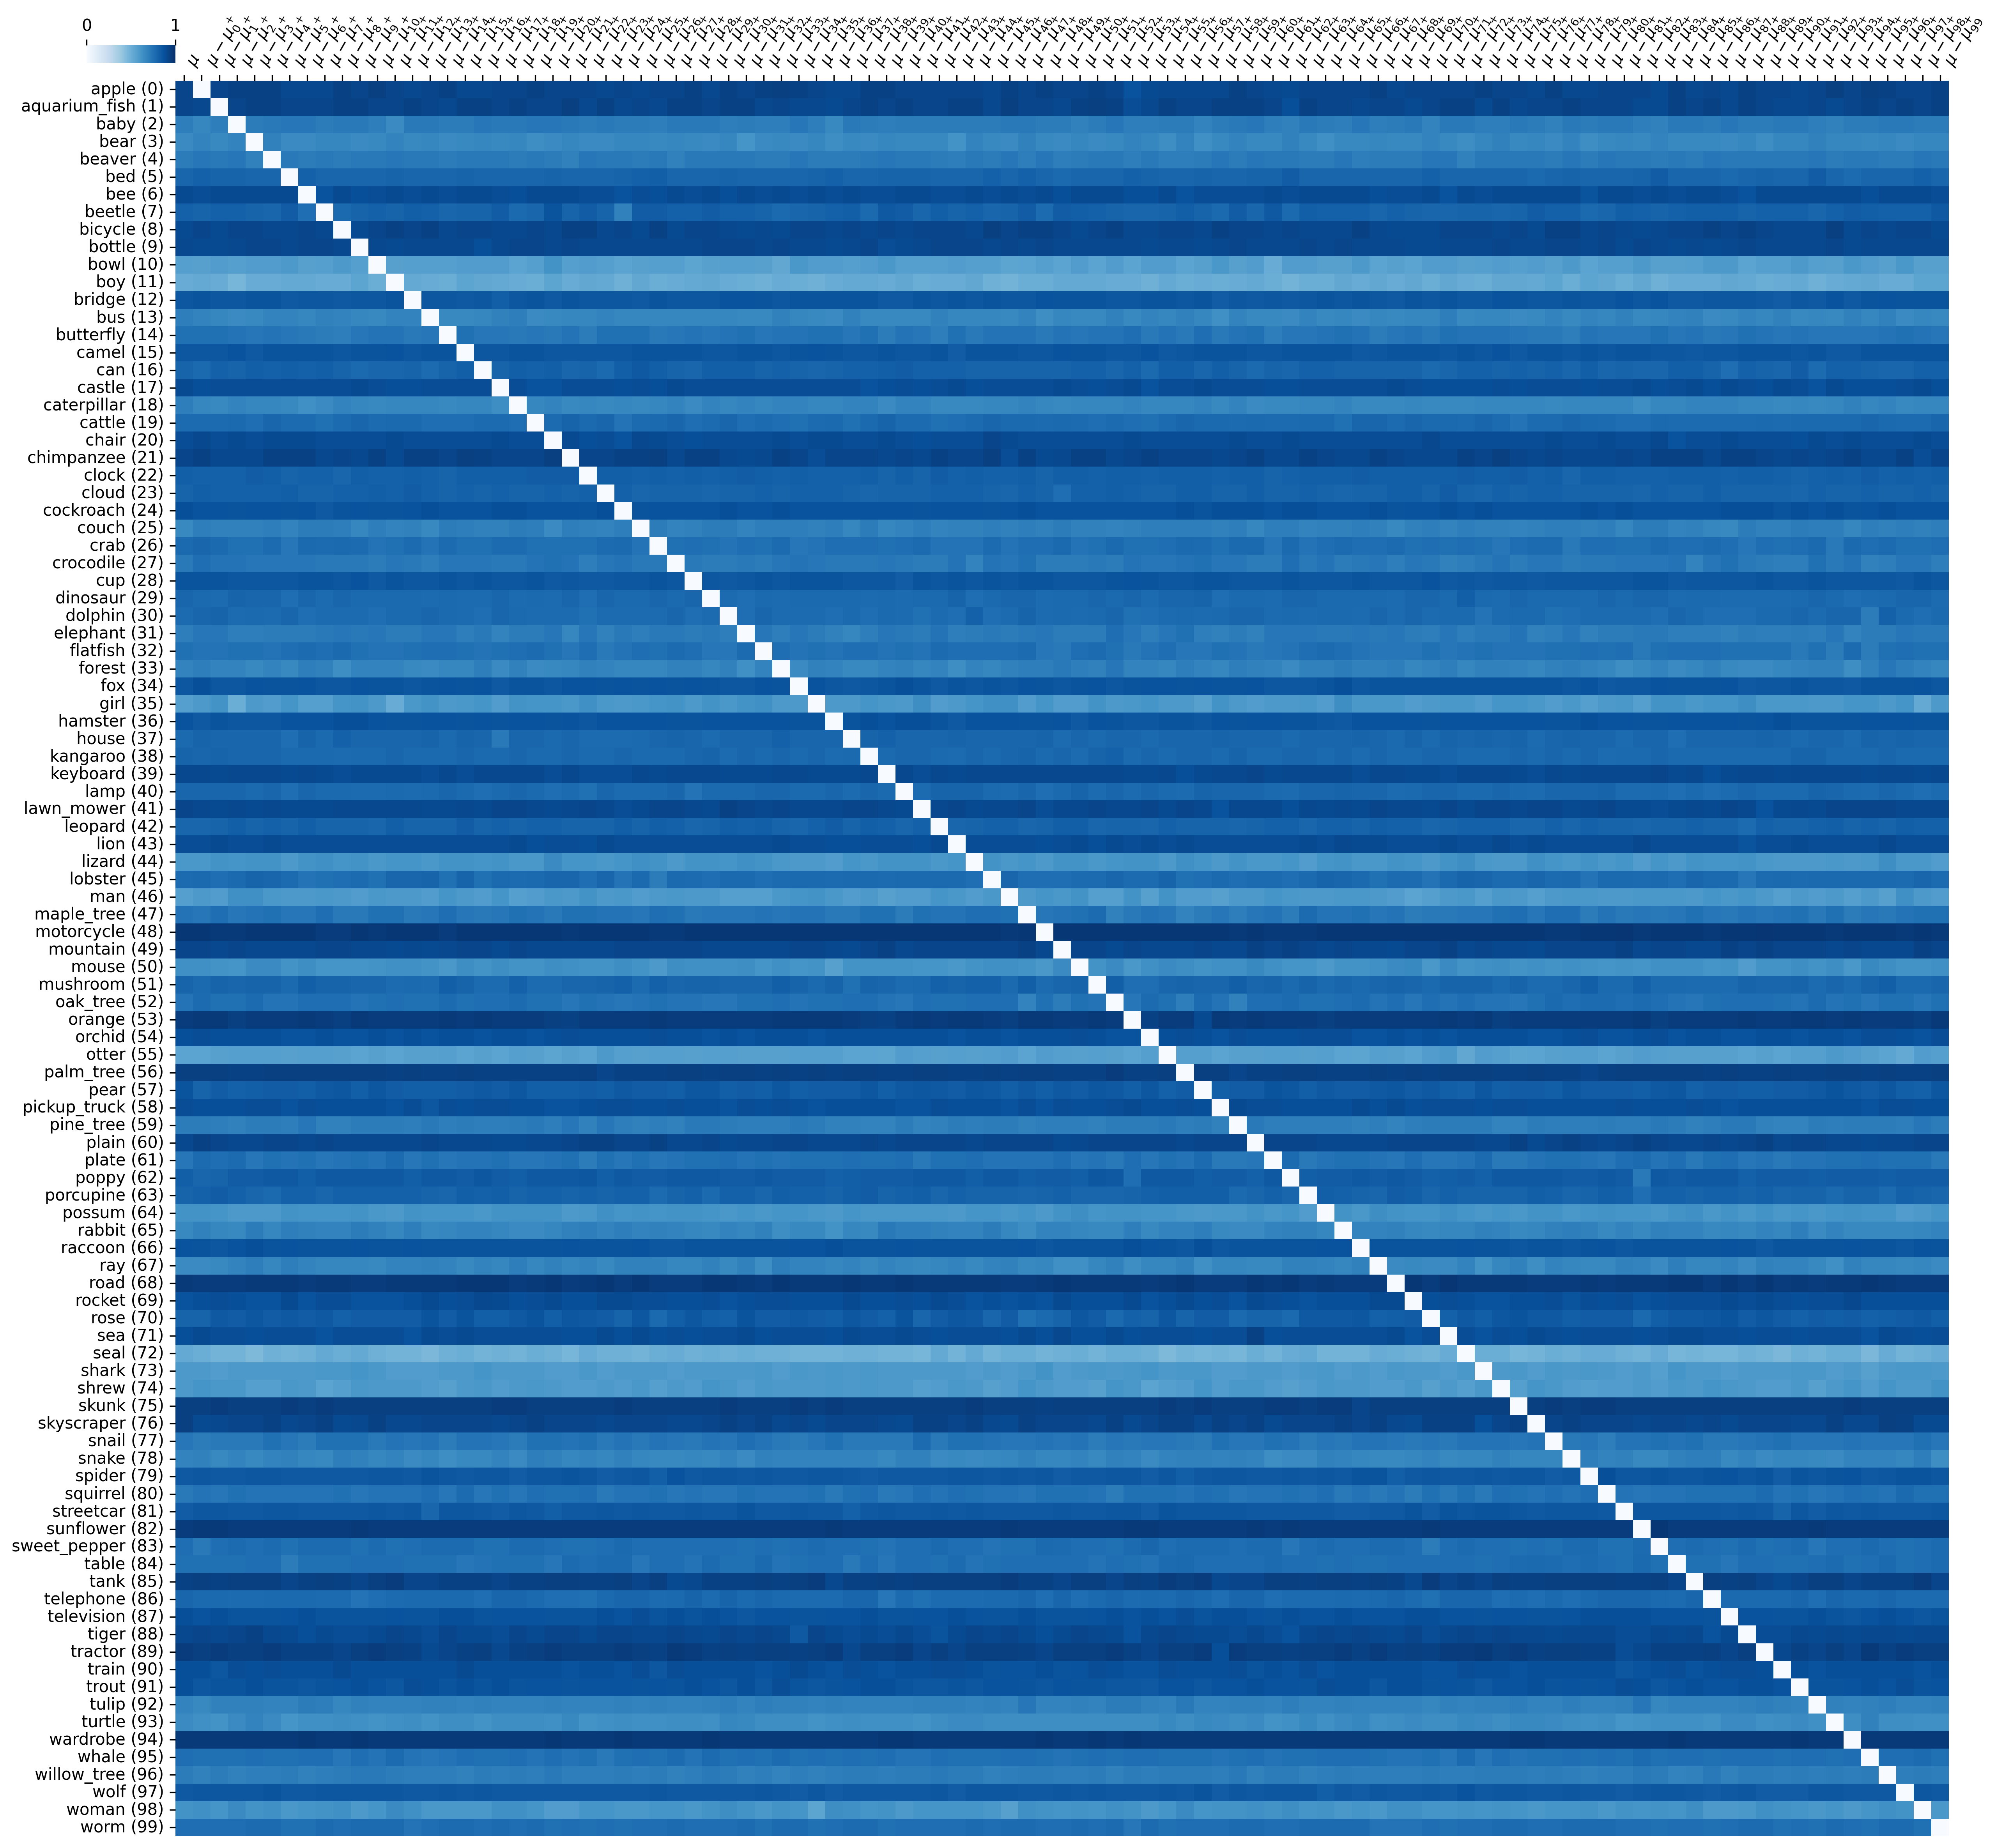

In [9]:
import matplotlib.pyplot as plt
import seaborn as sns
from mpl_toolkits.axes_grid1.inset_locator import inset_axes

fig, ax = plt.subplots(1, 1, figsize=(26, 19.5), dpi=300)
ax_ins = inset_axes(ax,
                    width="5%",
                    height="1%",
                    loc='lower left',
                    bbox_to_anchor=(-0.05, 1.01, 1, 1),
                    bbox_transform=ax.transAxes,
                    borderpad=0)

sns.heatmap(df, 
            cmap='Blues', 
            vmin=0, 
            vmax=1, 
            xticklabels=xticklabels, 
            yticklabels=yticklabels, 
            square=True, 
            ax=ax, 
            annot=False, 
            fmt='.2f',
            cbar_ax=ax_ins,
            cbar_kws={"orientation": "horizontal"})

ax.xaxis.tick_top()
ax.xaxis.set_label_position('top')
ax.set_xticklabels(ax.get_xticklabels(), rotation=60, ha='left')
ax.set_yticklabels(ax.get_yticklabels(), rotation=0)

ax_ins.xaxis.set_ticks_position('top')

fig.savefig('fig_resnet18_cifar100_classwise_accuracy.png', dpi=300, bbox_inches='tight')